# INFO 264, Group Exam 2025
### Kandidate numbers: 0000, 0000, 0000, 000
---
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
### <u>Noe av det som står at vi må ha med!!!</u>
#### Done ✓ <s>Important and relevant properties about the data</s>
#### Your preprocessing steps. For example: your process of feature selection and it's results, your choices when it comes to dimension reduction (why/why not/which method/why that method) etc.
#### Based on what you have learnt from the data, why do you think that your models are best-suited for the task
#### Why the particular parameters of a model that you use, work best
#### How you control over- and underfitting
#### Your choice of evaluaon methods. Which metrics did you choose and why? Addionally, you need to give an explanation based on your intuition about why given methods perform better or worse on the given task. 
#### Finally, as a concluding comment in the Jupyter notebook, you need to write a summary of your results, and discuss consequences of such results. 
#### Please provide the list of libraries you use in the form of a `requirements.txt` in the format used by pip. 

===============================-================================
# Introduction
---
### <u>The Assignment</u>
In this assignment, we were tasked with creating four machine learning models, one which have to be a neural network. These models will be used on a data set that among other data, inculdes 515.738 hotel reviews. The models will be used to analyze the reviews and label the sentiment in those reviews.

In addition to the four models for analyzing sentiment, we were tasked with creating a convolutional neural network that will be trained on the CIFAR-10 data set, specifically as a binary classifier on one of the categories in that data set.

### <u>The Process</u>
We'll take you through the process step by step, and to the best of our abilities, explain the how's and the why's of what we're doing. First up is the sentiment analysis with explaning the data, the preprocessing steps and lastly the models. Secondly we move on to the convolutional neural network, and the many itterations we had with that.

===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Spørmål til Seminarleder. Er AI disclaimeren under her, bra å ha med?
===================================================================
### <u>AI Disclaimer</u>
The use of AI in this paper is something we've been particulary conscious about. The members of the group has used different LLMs, including Gemini, ChatGPT and Copilot. But we've taken a different approach to the prompts we've been using, in contrast to what most other users are doing. The LLMs have been instructed not to provide any code, as to not influence how we structure our models. When showing code to these models, we've explained to the model what our understand of the code is, and asked it to confirm or reject that explination without any further comment from it. When stuck on something, the LLMs where instructed to provide a vauge hint on what we should look at in order to progress. 

# Task 1 Sentiment Analysis
---
## Exploratory data analysis and prepocessing
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Gain a sufficient understanding of the data for
model development and perform data cleaning and feature engineering steps if you find it
necessary. You may make any changes to your dataset; however, you must attempt to give a
reason as to why you find a given transformation necessary. 

===============================-================================

### <u>The data</u>
When looking at the data, we found many columns that where unnecessary for our sentiment analysis. Here we list them down with a small explanation as to why they where not relevant for us, as well as those that where relevant to us.
#### <u>Non relevant data</u>
* `Hotel_Address` - Since we're not maping out which locations have more negative or positive reviews, we found this column to be irrelevant.
* `Additional_Number_of_Scoring` - The data in this column made no sense to us, and so we where unable to find a meaningfull use for it.
* `Review_Date` - Knowing the data of which the review was written is not relevant for our analysis.
* `Average_Score` - The average score the reviewer gives, is not relevant to the task at hand, because it doesn't provide any information about their review.
* `Hotel_Name` - The name of the hotel, is not data that's relevant for sentiment analysis of the reviews.
* `Reviewer_Nationality` - The nationality of the reviewer does not help us identify the sentiment of their review.
* `Review_Total_Negative_Word_Counts` - The total amount of words in a review, tells us nothing about the actual sentiment in the review.
* `Total_Number_of_Reviews` - Does not give any information about the specific review.
* `Review_Total_Positive_Word_Counts` - The total amount of words in a review, tells us nothing about the actual sentiment in the review.
* `Total_Number_of_Reviews_Reviewer_Has_Given` - The amount of reviews the author has created, does not give us any information about the sentiemnt in the review.
* `Tags` - In our case, we found that the data was not relevant for us to predict the sentiment in the review.
* `Days_since_review` - Not relevant since it doesn't give any information about the sentiment in the review.
* `lat` - Knowing the latitude does not give valuable information about the review.
* `lng` - Knowing the longitue does not give valuable information about the review.

It's important to note that all of the data we chose to not include in our analysis, could be very usefull for other analysis tasks, or even if we where to expand on our sentiment analysis, we could use some of the data to for example see if reviewers nationality, and/or the hotels location, had any effect on the sentiemnt in the reviews. 

#### <u>Relevant data</u>
* `Negative_Review`- This column holds reviews that are labeled as negative, which is exactly what we need for analysing sentiemnt and make our prediction.
* `Positive_Review` - This column holds reviews that are labeled as positive, which is exactly what we need for analysing sentiemnt and make our prediction.
* `Reviewer_Score` - Super relevant as this will be served as our `target_labels`.

After looking thoroughly through the dataset, we found that many reviews had both positive and negative labeled reviews, and that we would have to combine those reviews to properly analyse the sentiment left by the reviewer. 
 

#### <u>Development data</u>
During development and testing, we quickly realized that using the whole data set wasn't particularly feasable, so we reduced the data set down to just 1000 lines, randomly picked thoughout the data set. This helped us quickly test changes whitout the need to go through the whole data set. The code below is what did that conversion for us.

The reduction code is no longer used since development and testing is done, but we chose to include it in this markdown block to show how we did it, and to prevent it from running and causing unneccesary errors.

```python
import pandas
import random

# Reduces a .csv to a smaller subset and make a new .csv
def csvReduxxion(_sPath, _sPathNew, _nSizeNew, _nRandomState, _sEncoding = "utf-8"):
    _dataset = pandas.read_csv(_sPath)
    _dataset.sample(n = _nSizeNew, random_state = _nRandomState).to_csv(_sPathNew, encoding = _sEncoding)

csvReduxxion("Hotel_Reviews.csv", "Hotel_Reviews_Reduced.csv", 1000, random.randint(0, 1000))

# Må kanskje bruke denne koden likevel for å redusere data til den siste modellen

### <u>Preprocessing steps</u>
#### <u>Preprocessing setp 1. Data extraction</u>
The function `extract_relevant_csv_data()`, takes in the provided csv file and extracts the data we deemed relevant for our assignment. In our case, this is the data contained in the columns `Negative_Review`, `Positive_Review` and `Reviewer_Score`. In a later step we combine the reviews into a single review. We could have done this now by just concatenating them, but we chose not to because we saw that an empty review had the text "No Positive" or "No Negative", depedning on the column. These entries are not part of a review, and so we wanted to remove them, which was easier to do during cleaning.

In [9]:
import pandas as pd

def extract_relevant_csv_data(file_path, use_cols = ["Negative_Review", "Positive_Review", "Reviewer_Score"]):
    dataset = pd.read_csv(file_path, usecols = use_cols)
    new_dataset = []
    for i in dataset.to_numpy():
        new_dataset.append({"Reviewer_Score": i[2], "Positive_Review": i[0], "Negative_Review" : i[1]})
    return pd.DataFrame(new_dataset)
data = extract_relevant_csv_data('./data/Small_Hotel_Reviews.csv')
extract_relevant_csv_data('./data/Small_Hotel_Reviews.csv') # To display the data below

,Reviewer_Score,Positive_Review,Negative_Review
0,7.5,One staff member at reception recommended a r...,The room was spacious and had a good view
1,6.7,The room is not satisfying,Good service
2,9.2,My expo fair was far,Fantastic staff and decoration
3,7.1,They don t have any helping or can do even se...,I didn t received any welcome attitude while ...
4,7.5,Bed mattress was thin and uncomfortable The i...,Location and price are excellent Staff is fri...
...,...,...,...
995,9.6,Entrance Don t worry though because I side is...,Very friendly staff
996,7.9,Room service was poor difficult to connect wi...,The room was lovely but there was no kettle i...
997,10.0,The room was a little small,Great value for money Fantastic location Very...
998,5.8,we have 3 single bed instate 1 single and 1 d...,i like about this hotel just the breakfast an...


#### <u>Preprocessing step 2. Cleaning</u>
After extracting what we need from the csv file, the relevant data is ready for some more structuring and cleaning. The function `combine_reviews()` was used for this purpose. `combine_reviews()` will first call `clean_sentences()` to clean the reviews by removing special characters, numbers, single characters, replace multiple spaces with one space, remove prefixes, convert to lowercase, lemmatize the words and remove stopwords. All this is done to get more consistent text, as well as remove unnecessary words that only serve to create noise for the models and increase the vocabulary.

##### <u>Deeper explanation</u>
* Semantic meaning:
    * Removing special and single characters, numbers, prefixes and converting to lowercase, are all instances that we chose to remove because they generally don't add semantic meaning to sentences. Some of them also increase the vocabulary because something like "room!" and "room?", or "Room" and "room", will be treated as two different words. This is definitley something that we don't want, since increasing the vocabulary, increases the complexity of the model and uses more memory. It can also lead to overfitting if the training data is limited. We recognize the importance of having a deecent sized vocabulary, but having the same words take up different slots in the vocabulary is not good. We should also mention that some special characters like emjois, can carry sentiment meaning, as well as typing in all capital letters. This can lead to some unreliable results, but these types of characters are not pressent in our dataset to the point where it would actually affect the results. Also important to note that removing prefixes, can change the meaning of words, which can also effect the results.

* Tokenization:
    * Converting multiple spaces to one space, is an important consistency for tokenization. If we dont remove multiple spaces, the tokenization can incorrectly use these spaces as delimiters, resulting in an empty token

* Stopwords
    * `"stopwords"` is a standardized list of words that don't carry much referential meaning. But these classes of words like pronouns, subjunctions, prepositions, etc. are arguably very important for language analysis, since they define the structure of the sentence and the relations between constructions in the sentence, and the reference they carry to the real world. But we decided to exclude the structural words, since it would take more complex language analysis to include sentence structure as part of the analysis, and we believe that we can get good enough analysis from just the referential words. The assumption is that if the reviewer wants to talk about what was bad about a hotel, they are likely to use some adjectives over others. We assume it's a lot more likely that a reviewer would use a word like "uncomfortable", "dirty", or "terrible", when they are giving a bad review, and words like "comfortable", "clean", or "amazing" when they are giving a good review. With this assumption, the actual larger structure of the sentence doesn't mean as much, and thus structural words aren't needed. It's also important to note that some stopwords can have sentiment meaning or change the sentiment of a sentence if removed, but due to the assumptions made above, we think that it will have very litle impact on results. Removing stopwords helps with reducing vocabulary size, which can result in a smaller memory footprint, faster training, improved learning on frequent words and reduce overfitting on rare words.

* Lemmatizing words
    * Lemmatizing reduces words to their base, dictionary form. This means that we take words that derive from the same core and reduce them to the same word representing the core. For example, the words "connect", "connection", "connecting", etc, all derive from "connect" and will all be replaced by that word. The argument for lemmatizing is similar to that of stopwords, we assume that different forms of the same word have similar enough meaning and usage that we can get a good enough statistical analysis by just treating them as the same word. Lemming will always produce valid words, as well as consider context. This is opposed to Stemming, which might produce words that have no meaning, and does not look at context, hence why we dont use Stemming at all. It's important to note that lemmatization comes at a greater computational cost compared to Stemming, but the increased cost is generally worth it. `WordNetLemmatizer()` uses a dictionary dataset, downloaded from NLTKs `"wordnet"`. This dictionary is structured in a way that helps the lemmatizer to capture semantic relationship between words.

##### <u>A few notes</u>
We've commented-out the `"stopwords"` and `"wordnet"` downloads, because these downloads are downloaded to the system, not the project, which means that you only need to download them once. We could remove the code, but chose to keep it with regards to the exam.

Duplicates is something we considered, but we came to the conclusion that there were no uniqe identifiers in the data, so therfore it was impossible for us to determine if something that looked like a duplicate entry, was in fact a duplicate entry. Because of that we chose to not look for duplicates.

In [279]:
# The clean_sentences function has been heavily inspired by "https://stackabuse.com/text-classification-with-python-and-scikit-learn/" text processing.
 
# import nltk # Needed to download 'stopwords' and 'wordnet'.
# nltk.download('stopwords') # Needed for downloading 'stopwords' one time.
# nltk.download('wordnet') # Needed for downloading 'wordnet' one time.

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
import re
from nltk.stem import WordNetLemmatizer

# An indenpendent function that cleans the sentences up.
# Returns a list of the cleansed sentences, and the data variable which was used.
def clean_sentences(data):
    all_text = []
    for sen in range(0, len(data)):
        # Remove all the special characters
        text = re.sub(r'\W', ' ', str(data.iloc[sen]))
        # Remove all numbers
        text = re.sub(r'\d', ' ', text)
        # remove all single characters
        text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
        # Remove single characters from the start
        text = re.sub(r'\^[a-zA-Z]\s+', ' ', text) 
        # Substituting multiple spaces with single space
        text = re.sub(r'\s+', ' ', text, flags=re.I)
        # Removing prefixed 'b'
        text = re.sub(r'^b\s+', '', text)
        # Lemmatization
        text = text.split()
        # Converting to Lowercase
        for c in range(len(text)):
            text[c] = text[c].lower()

        text = [WordNetLemmatizer().lemmatize(word) for word in text if word not in (stop_words)]
        text = ' '.join(text)

        all_text.append(text)
    return all_text

def combine_reviews(data):
    X_1, X_2 = clean_sentences(data["Negative_Review"]), clean_sentences(data["Positive_Review"])
    X = []
    for n in range(len(X_1)):
        if X_1[n] and X_2[n] is None:
            pass
        elif X_1[n] == 'negative' or X_1[n] is None:
            X.append(X_2[n])
        elif X_2[n] == 'positive' or X_2[n] is None:
            X.append(X_1[n])
        else:
            X.append(X_1[n] + " " + X_2[n])
    return pd.array(X)

def target_score_to_expression(data):
    y_n = data["Reviewer_Score"].values
    y = []
    for value in y_n:
        if value < 6:
            y.append("negative")
        elif value < 8:
            y.append("neutral")
        else:
            y.append("positive")
        
    return pd.array(y, dtype='object')

### Model preprocessing steps
All of our models goes through these steps in some way or another, but the functions used is dependent on the model.

1. <u> The first three models</u>
    * Uses the data that `extract_relevant_csv_data()` extracts from the csv file.
    * `combine_reviews()` will first call `clean_sentences()` to clean the reviews, and then combine them.
    * For the evaluation of our models, we decided that using `accuracy` would be the best metric to train our models. Since it's creating a recognizable pattern for negative, neurtal and positive.

2. <u>The LSTM model uses the following:</u>
    * The `target_score_to_n` function is used to convert the score associated with each review, into one-hot encoded labels `[0, 1, 0]`. This is done to represent the target classes `negative`, `positive` and `neutral`. By converting the classes to numerical arrays, we make them suitable for training. One-hot encoding labels are also needed when using loss functions like `categorical_crossentropy`.
    * This is all done to standardize the text and reduce noice, which helps the LSTM model focus on meaningful patterns

3. <u>The KNN model uses the following:</u>
    * We start similarly to LSTM and convert the score into labels `[0, 1, 0]` and make the target classes into `negative`, `positive` and `neutral`, but before we seperate the training and test data we convert the one-hot encoded labels to either `0, 1 or 2`. This is done to fit better into our KNN model.

4. <u>The NLP model uses the following:</u>
    * For our target data we use `target_score_to_expression` which takes the `reviewer_score` from the dataset to represent them with `negative`, `positive` and `neutral`. Here we don't use one-hot encoded labels since it's more readable than, `[0, 1, 0]`. The target value isn't really that relevant when training our model so that's why we chose a more readable approach.
    * In addition we use a `CountVectorizer` to turn our `review_strings` to a fitted `bag_of_words` for our model which you will see below.

5. <u>The CNN model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

### b) Models
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Build four (4) machine learning models for labelling sentiment behind hotel reviews.
One of the models needs to be a neural network (e.g. LSTM). You are welcome to train
models that are not covered in the course. Evaluate the performance of the built models
using the appropriate evaluation metrics 

===============================-================================

##### When building our LSTM model and how to preprocess we used this repository as a guideline to create a suitable model for our task: "https://github.com/sergiovirahonda/TweetsSentimentAnalysis/blob/main/TweetsSentimentPredictions.ipynb"

#### Model Imports
All the imports needed for our models

In [280]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
from gensim.models import Word2Vec;
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import layers, datasets, models, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from typing import Iterable
warnings.filterwarnings('ignore')

Combine the negative and positive reivew column on each row. During the combining process, the words are also cleaned by removing special characters, single characters, multiple spaces, prefixes and at the end it also lemmatizes the words.

In [281]:
X = combine_reviews(data)
y = target_score_to_expression(data)

One-hot encode the labels

In [282]:
def one_hot_encode(y_data):
    labels = np.array(y_data)
    y_data = []
    for i in range(len(labels)):
        if labels[i] == 'neutral':
            y_data.append(0)
        if labels[i] == 'negative':
            y_data.append(1)
        if labels[i] == 'positive':
            y_data.append(2)
    y_data = np.array(y_data)
    labels = tf.keras.utils.to_categorical(y_data, num_classes = 3)
    return labels

In [ ]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Med fullført preprocessing så har vi følgende mengde ord:
# 10331478 ord
# 73439 unike ord
# 18941 ord forekommer 5 ganger eller mer
# 95% av reviews er 55 ord eller færre 
# ===================================================================

#### LSTM Model

Since we had to use a neural network we chose the recomended one which was LSTM. We have tried and failed many times with this model, but with a little guideline we have created a very optimal solution to the task. As we change weights based on accuracy it will most likely be the best model. In addition it is quite more powerful than some of the other models we have used.

For faster training, we have opted to use tensorflow with a GPU.

In [283]:
max_words = 5000
max_len = 55

# Tokenize and pad the data.
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
reviews = pad_sequences(sequences, maxlen = max_len)

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(reviews, labels, random_state = 0)

#### Training the LSTM model

We add an ``Embedding`` with the ``max_words`` since this is how many features we have in our tokeinzer. Next we add a ``Masking`` with the ``mask_value`` set to 0 to skip any timestep equal to the ``mask_value``. Then a layer with 20 units of ``LSTM`` with a ``dropout`` of 0.3 to prevent overfitting. We use the ``activation="relu"`` since this activation is efficient and works nicely with sentiment analysis. In our last layer we create an output layer with 3 ``Dense`` units with an ``activation="softmax"`` since we mostly want a prediction percentage than a float value between for example -200 and 200. In our compiler we use an ``optimizer="rmsprop"`` which works quite nicely with our task, in addition we look at out ``loss`` based on the `categorical_crossentropy` which is the best loss method for our task with 3 outputs with ``one-hot encoders``. As we said earlier we use the metric `accuracy` to train our model to be the best. In addition we add a `ModelCheckpoint` to save the best model we got under our training. We also have an`` early_stopping`` method that stops the epochs if ``val_loss`` does not improve over 5 epochs.

In [285]:
with tf.device('/GPU:0'):
    model_LSTM = Sequential()
    model_LSTM.add(layers.Embedding(max_words, 20))
    model_LSTM.add(layers.Masking(mask_value = 0))
    model_LSTM.add(layers.LSTM(20, dropout = 0.3, activation = 'relu'))
    model_LSTM.add(layers.Dense(3, activation = 'softmax'))
    model_LSTM.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

    # Implementing model_LSTM checkpoins to save the best metric and do not lose it on training.
    checkpoint_LSTM = ModelCheckpoint("best_model.keras", monitor = 'val_accuracy', verbose = 1, save_best_only = True, mode = 'auto', save_weights_only = False)
    history_LSTM = model_LSTM.fit(X_train_LSTM, y_train_LSTM, epochs = 50, batch_size = 256, validation_data = (X_test_LSTM, y_test_LSTM), callbacks = [checkpoint_LSTM, early_stopping])

Epoch 1/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step - accuracy: 0.1211 - loss: 1.1030
Epoch 1: val_accuracy improved from -inf to 0.68000, saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.2577 - loss: 1.1000 - val_accuracy: 0.6800 - val_loss: 1.0896
Epoch 2/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6250 - loss: 1.0912
Epoch 2: val_accuracy did not improve from 0.68000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6482 - loss: 1.0890 - val_accuracy: 0.6800 - val_loss: 1.0811
Epoch 3/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6953 - loss: 1.0796
Epoch 3: val_accuracy did not improve from 0.68000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6684 - loss: 1.0799 - val_accuracy: 0.6800 - val_loss: 1.0725
Epoch 4/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6914 - loss: 1.0720
Epoch 4: val_accuracy did not improve from 0.68000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6679 - loss: 1.0715 - val_accurac

In [286]:
# Load the best model obtained during training
best_model_LSTM = keras.models.load_model("best_model.keras")

In [287]:
# Evaluate the model and print out the accuracy.
test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose = 2)
print('Model accuracy: ', test_acc_LSTM)

8/8 - 0s - 29ms/step - accuracy: 0.6800 - loss: 1.0896
Model accuracy:  0.6800000071525574


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


<Axes: >

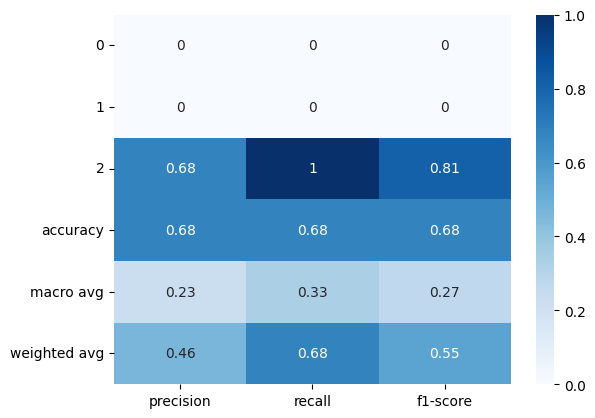

In [288]:
# Create a classification report and use seaborn to show it.
predictions_LSTM = best_model_LSTM.predict(X_test_LSTM)
clf_report_LSTM = classification_report(np.argmax(y_test_LSTM, axis = 1), np.argmax(predictions_LSTM, axis = 1), output_dict = True)


sns.heatmap(pd.DataFrame(clf_report_LSTM).iloc[:-1, :].T, annot=True, cmap="Blues")

<Axes: >

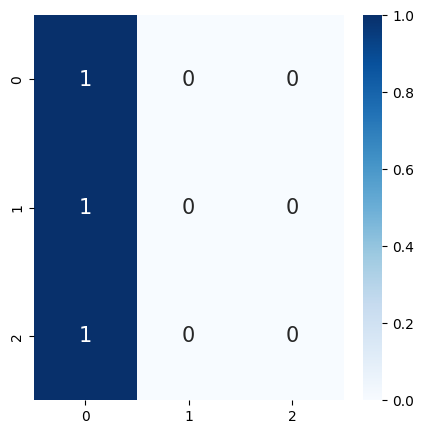

In [289]:
# Create a confusion matrix.
matrix_LSTM = confusion_matrix(y_test_LSTM.argmax(axis = 1), np.around(predictions_LSTM, decimals=0).argmax(axis = 1))

conf_matrix_LSTM = pd.DataFrame(matrix_LSTM, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix_LSTM = np.array(conf_matrix_LSTM).astype('float') / np.array(conf_matrix_LSTM).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix_LSTM, annot = True, annot_kws={"size": 15}, cmap = "Blues")

8/8 - 0s - 4ms/step - accuracy: 0.6800 - loss: 1.0896


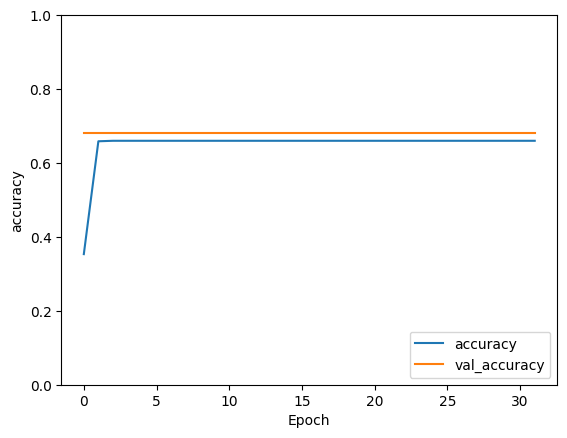

In [290]:
# Create a graph to check overfitting and underfitting.
plt.plot(history_LSTM.history['accuracy'], label='accuracy')
plt.plot(history_LSTM.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)

#### KNN Model

We started with a KNN model that used the columns ``Review_Total_Negative_Word_Counts``, ``Review_Total_Positive_Word_Counts`` and ``Average_Score``. This got a result that only predicted based on how many positive or negative words there were, not the review text as the task asked for. In addition we also wanted to use the same data for all of our models so we swtiched our approach on KNN. After some testing we found that using ``TfidfVectorizer`` (Term Frequency-Inverse Document Frequency) was the right way to go:
* Term Frequency is how often a word appears in a text.
* Invers Document Frequency reduces the weight of common words across multiple documents while increasing the weight of rare words.
We used this to categorize the words into different levels of importance. We use the min_df = 5 to say that a word needs to be found at least 5 times to count.  
After some testing we used ``KNearestNeigbour`` with 13 neighbours and 20% of the data to train and the rest of the set to predict the result.

We evaluate the data with both a classification report and confusion matrix. We also check with a graph to calculate overfitting and/or underfitting.

Source: https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/


Convert the one-hot encoded labels to a 1D array.

In [291]:
labels_convert_KNN = one_hot_encode(y)
labels_convert_KNN = np.argmax(labels_convert_KNN, axis=1)

Vectorizing the reviews, we use the same features as our tokenizer in the LSTM model.

In [292]:
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 1), min_df = 5)
vectorize_reviews = vectorizer.fit_transform(X) 

Split the data into training and testing sets. Testing on 20% of the data with a random state at 42 because that's the answer to life, the universe, and everything

In [293]:
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(vectorize_reviews, labels_convert_KNN, test_size = 0.2, random_state = 42)

After a lot of time we found that KNN is a higly inneficient method compared to the other models. More details on this in the conclution.

In [294]:
k = 13
model_KNN = KNeighborsClassifier(n_neighbors = k)
model_KNN.fit(X_train_KNN, y_train_KNN)
y_pred_train = model_KNN.predict(X_train_KNN)
y_pred_test = model_KNN.predict(X_test_KNN)

Creating a classification report
Create a classification report and use seaborn to show it.

<Axes: >

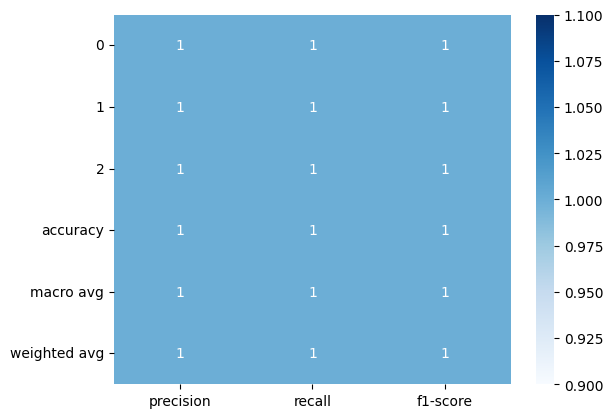

In [295]:
y_pred_KNN = model_KNN.predict(X_test_KNN)
clf_report_KNN = classification_report(y_test_KNN, y_test_KNN, output_dict = True)

sns.heatmap(pd.DataFrame(clf_report_KNN).iloc[:-1, :].T, annot = True, cmap = "Blues")

Creating a confusion matrix

<Axes: >

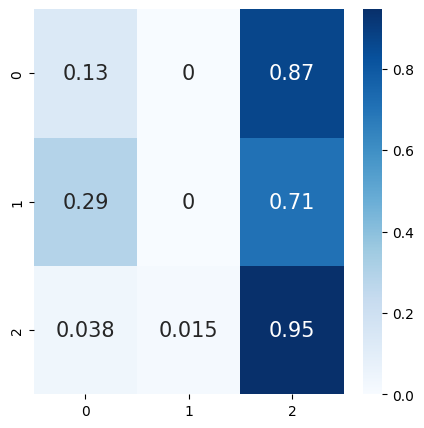

In [296]:
matrix_KNN = sklearn.metrics.confusion_matrix(y_test_KNN, y_pred_KNN)

conf_matrix = pd.DataFrame(matrix_KNN, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot = True, annot_kws = {"size": 15}, cmap = "Blues")

Creating a graph to check over/under-fitting

Training Accuracy: 0.7
Testing Accuracy: 0.65

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.13      0.19        45
           1       0.00      0.00      0.00        24
           2       0.69      0.95      0.80       131

    accuracy                           0.65       200
   macro avg       0.34      0.36      0.33       200
weighted avg       0.53      0.65      0.57       200



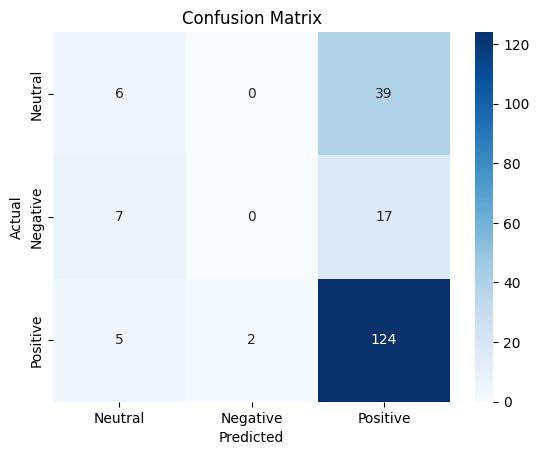

In [297]:
print("Training Accuracy:", accuracy_score(y_train_KNN, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test_KNN, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test_KNN, y_pred_test))

conf_matrix = confusion_matrix(y_test_KNN, y_pred_test)
sns.heatmap(
    conf_matrix, annot = True, fmt = 'd', cmap = 'Blues',
    xticklabels = ['Neutral', 'Negative', 'Positive'],
    yticklabels = ['Neutral', 'Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## TRENGS Å KJØRE PÅ NYTT, FEIL K


This output shows that the model is heavily leaning towards a positive result, where almost all of the entries is registerd as positive. The model also gives many false positives that should be neutral or false. The training set has a fairly high accuracy with ~69% correct and the actual testing set has an accuarcy of 66% which is also fairly high. The model also has low overfitting. 



#### NLP Model

We use this model since Natural Language Processing models are widely used when tackling sentiments analysis.

As per "Zubair Ashfaque" from "https://medium.com/@zubairashfaque/sentiment-analysis-with-naive-bayes-algorithm-a31021764fb4":  

__Sentiment Analysis with the Naive Bayes algorithm is a powerful approach, using probability and linguistic analysis to categorize text sentiments as positive, negative, or neutral. By preprocessing text, calculating log priors, and deriving log-likelihoods, this method quantifies sentiment, guiding accurate classification.__

<br>

After doing some testing with both `MultinomialNB` and `BernoulliNB` we found that `MultinomialNB` had the best accuracy with our data which is our score metric to our models. In addition we also experimented with `CountVectorizer` and `TfdifVectorizer` and found that `CountVectorizer` was a better fit with the data to get the most accurate model. Even though `TfdifVectorizer` was better overall at finding positive reviews.

In [298]:
# Since the dataset is so huge, we use the 5000 of the most common words, and we want to use the words that contains in at least 5 reviews. In addition we use words
# that are in a maximum of 60% of our reviews to remove non meaningful words.
cv = CountVectorizer(max_features = 5000, min_df = 5, max_df = 0.6)
X_nlp = cv.fit_transform(X)

X_train_NLP, X_test_NLP, y_train_NLP, y_test_NLP = train_test_split(X_nlp, y, test_size = 0.2, random_state = 42)

In [299]:
# Train the model
print("MultinomialNB:")
nlp_model = MultinomialNB()
nlp_model.fit(X_train_NLP, y_train_NLP)

MultinomialNB:


MultinomialNB()

In [33]:
# Train the model
print("MultinomialNB:")
nlp_model = MultinomialNB()
nlp_model.fit(X_train_NLP, y_train_NLP)

MultinomialNB:


MultinomialNB()

{'negative': {'precision': 0.4375, 'recall': 0.2916666666666667, 'f1-score': 0.35, 'support': 24.0}, 'neutral': {'precision': 0.34285714285714286, 'recall': 0.26666666666666666, 'f1-score': 0.3, 'support': 45.0}, 'positive': {'precision': 0.7718120805369127, 'recall': 0.8778625954198473, 'f1-score': 0.8214285714285714, 'support': 131.0}, 'accuracy': 0.67, 'macro avg': {'precision': 0.5173897411313518, 'recall': 0.47873197625106023, 'f1-score': 0.49047619047619045, 'support': 200.0}, 'weighted avg': {'precision': 0.6351797698945351, 'recall': 0.67, 'f1-score': 0.6475357142857142, 'support': 200.0}}


<Axes: >

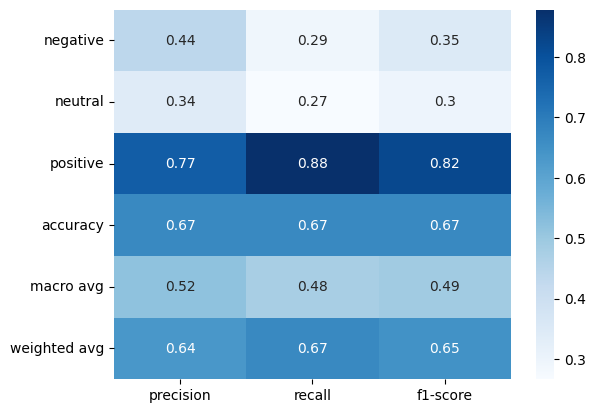

In [300]:
# Creating a classification report
y_pred_nlp = nlp_model.predict(X_test_NLP)
clf_report_NLP = classification_report(y_test_NLP, y_pred_nlp, output_dict = True)
print(clf_report_NLP)

sns.heatmap(pd.DataFrame(clf_report_NLP).iloc[:-1, :].T, annot = True, cmap = "Blues")

<Axes: >

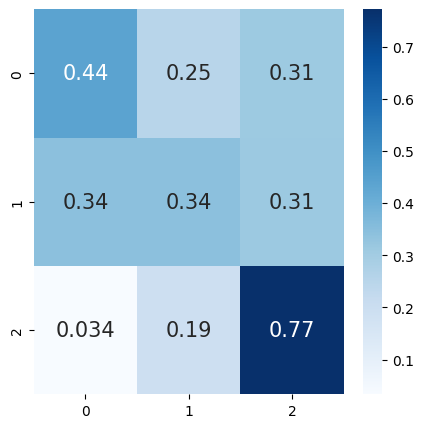

In [301]:
# Creating a confusion matrix
matrix_nlp = sklearn.metrics.confusion_matrix(y_pred_nlp, y_test_NLP)

conf_matrix = pd.DataFrame(matrix_nlp, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot = True, annot_kws = {"size": 15}, cmap = "Blues")

In [303]:
# Creating a graph to check over/under-fitting

# plt.plot(nlp_model.history['accuracy'], label = 'accuracy')
# plt.plot(nlp_model.history['val_accuracy'], label = 'val_accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('accuracy')
# plt.ylim([0.0, 1])
# plt.legend(loc = 'lower right')

# test_loss, test_acc = nlp_model.evaluate(X_test_NLP, y_test_NLP, verbose = 2)

TypeError: 'MultinomialNB' object is not subscriptable

#### CNN Model

We thought it would be cool to try and use a convolutional network for sentiment analysis of the reviews.

##### <u>Model note</u>
This model operates slightly differnt to the previous models, so it prepears and cleans the data a little bit different than the other models. It inherently does the same, but we will explain any deviation from the other models.

MYE AV DETTE KAN FLYTTES OPP

##### <u>Preparation</u>
This model loads the data on it's own, but fetches the exact same data as the other models. The model then concatenates the reviews and stores them in a variable, as well as storing the review scores in another. 

Further, the review score value is rounded and a category id is assigned to the review based on its score: 
* negative: 0 through 6 
* neutral: 7 through 8 
* positive: 9 through 10. 

Then the output category ids are one-hot encoded for each review.

The `dataset_preparation()` function handles the lemmatization of the words, removal of stop words and cleans the data. The data is returned in a clean state, together with the length of the review with the most words. 

##### <u>Vectorization</u>

The words are then converted to vectors to reduce processing time. The function `dataset_vectorization()` is used for this. The word-vectors cannot have just one channel with the word encoded into a number as an id representing it because of how gradient descent works. The neural network uses gradient descent, which assumes that the function is continuous, that the output interpolates smoothly between two input vectors, as the values of one vector interpolate into the other vector. This excludes id encoding, because words with ids close to each other are not at all guarranteed to have similar meanings, and for one dimension, it is basically impossible as the set of words grows, given that words have many "axies" of meaning.

One-hot encoding won't work either:
1. Because it would require a number of channels for the word-vector equal to the number of words. This excludes this approach because of how much memory and processing time it would require.

2. Because the input vectors would be far to sparse with meaning to draw anything out of, which is why this encoding style isn't used for these kinds of networks. //// SOURCE

One solution to this is turning the words into vectors using a system that can somehow figure out commonalities between the words or how they relate to each other or any kind of pattern, and then figure out a number of "axies" of meaning for each word. One such system is implemented by the `Word2Vec` class in `gensim`. It takes a model for vectorization and trains itself according to the model and a set of words provided. After this, a word can be inputted to the Word2Vec instance, and it will return an array of values. This array is the vector we use to represent the word, which we feed into the network. //// SOURCE

After this step, the array structure should look something like this:
```python
datasetX: [ [ [ float32, ... (k) ], ... (m) ] ... (n) ]
```
where `n` is the number of reviews, `m` is the length of the review, and `k` is the dimension of the word-vector.

We see that the reviews may have varying numbers of words, meaning that the arrays of word vectors would vary in length. To feed the array into the network, it needs to be converted to a tensor. The problem is that tensors are required to be like transcendentally rectangular, and the arrays of words varying in length is not comaptible with that. We did assume that a CNN with a convolutional layer as the input would be able to account for this, since the layer just strides from one end of the texture to the other, but apparently tensorflow doesn't like that.

# ==== IVAN Er dette riktig? =====
To solve this, I just padd the reviews to the length of the longest review, with word vectors where all the numbers are 0. This should be fine, since the vectorizer makes word vectors with values from -1 to 1, so 0 would be neutral; that the word vector has no meaning on that axis.
# ========================

The number of fragment channels was chosen based on testing. A larger number of channels consistently gave better results, and we assume that this trend would probably continue up until a number of channels that is some larger fraction of the total number of unique words in all the reviews, but more channels increases memory usage and training time, so we never really got to test this theory on the entire dataset. We assume that as the number of channels reaches past a quarter of all the unique words, the network would start to perform worse, since there would be too many channels and not enough words to generate meaning, leading to a similar situation as the one-hot encoding, that when it equals to the number of unique words, it would be equivalent to be like a padded out one-hot encoding. Again, we didn't get to actually test the one hot encoding, and we didn't get to test larger numbers of channels, so we can't really show data to attest to this theory.


##### <u>Defining the model</u>

The model uses a convolutional layer as input. The size and stride length of the filters was chosen based on testing. We found that these values were the ones that gave the best results. //// DOUBLE CHECK THIS: // A to small of a filter didn't perform very well. We theorize that this is because words in a sentence relate to each other across larger distances in a stream of speech or text, so a wider filter would do better. What we also saw was that when the filter was too large, it performed worse. We theorize that this is because words that are to far appart, don't mean much for each other, at least not as much as words that are close to each other, so they would mostly just be noise in the filter.

The 1D convolutional layer, gives a 2D output because there is a neuron for each channel of the fragments in the texture, so there is 1 dimension from the fragment channels and 1 dimension from the convolutional layer dimensionality. We use a flatten layer after the convolutional layer to turn the 2D output of the layer into a 1D output. All the outputs are kept in tact, just sequenced into a line.

We use a couple more layers after the convolutional layer to properly interpret the output of it and narrow it down to the three categories:
* positive 
* neutral
* negative

We use dropout layers in between the other layers, because by disregarding some of the inputs from one layer to the next, it makes the network more resilient. If a layer can't rely on the value of a neuron to always be usable, it has to find other patterns to reinforce, which makes the network spread the pattern recognition wider across the neurons in the layer.
//// SOURCE: https://medium.com/@utsavraj.ptn04/dropping-the-knowledge-bomb-understanding-dropout-layers-in-deep-learning-0612f517269d

The model uses early stopping in relation to loss. This is because if the model starts to perform worse with training, it is important to stop it when it is close to its peak. We have given the model a higher patience value, this is because we wanted it to try a little harder before giving up. This relates to the graphs that we saw, where accuracy tended to have some ups and downs, so the model should be a little more cool and levelheaded and hold the stocks a little longer. Also it was a bit sad to see the model give up after 10 out of 50 epochs.


In [304]:
#############
# DATAFRAME CONVERZZION

def dataframe_convertion(_dataset):
    _merged_reviews = []
    for i in _dataset.to_numpy():
        _merged_reviews.append({ "score": i[2], "review": i[0] + " " + i[1] })
    
    return _merged_reviews

In [305]:
#############
# DATASET EXTRAXXION

from typing import Iterable

def entry_extraction(_entry, _col):
    _entry_extract = []
    if isinstance(_entry[_col], Iterable):
        for _word in _entry[_col]:
            _entry_extract.append(_word)
        return _entry_extract
    else:
        return _entry[_col]

def dataset_extraction(_dataset, _col):
    _dataset_extract = []
    for _entry in _dataset:
        _entry_extract = entry_extraction(_entry, _col)
        _dataset_extract.append(_entry_extract)
    return _dataset_extract

In [306]:
#############
# DATASET PREPARATION

import re
import nltk

def string_clean(_string):
    _string = _string.lower()
    _string = re.sub(r"\d+", "", _string)
    _string = re.sub(r"[^\w\s]", "", _string)
    return _string

def lemma_string(_string):
    _text = nltk.word_tokenize(_string)
    _text_lemma = []
    for _word in _text:
        _word_lemma = WordNetLemmatizer().lemmatize(_word)
        if not _word_lemma in stop_words:
            _text_lemma.append(_word_lemma)
    return _text_lemma

def dataset_preparation(_dataset, _mode = "lemma"):
    _dataset_prepare = []
    _entry_longest = 0
    if _mode == "lemma":
        for _review in _dataset:
            _review_prepare = { "score": _review["score"], "review": lemma_string(string_clean(_review["review"])) }
            _dataset_prepare.append(_review_prepare)
            if len(_review_prepare["review"]) > _entry_longest:
                _entry_longest = len(_review_prepare["review"])
    else:
        raise ValueError("provided preparation mode does not exist")

    return _dataset_prepare, _entry_longest

In [307]:
#############
# SCORE: (abstract python decimal number) TO LABEL CONVERZZION

const_label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2,
}

const_score_map = {
     0: 0,
     1: 0,
     2: 0,
     3: 0,
     4: 0,
     5: 0,
     6: 0,
     7: 1,
     8: 1,
     9: 2,
    10: 2,
}

def entry_label_convertion( _score ):
    return const_score_map[round(_score)]

In [308]:
#############
# DATASET SPLITTING / VECTORIZATION

import random
import numpy as np

# im doing it like this because it saves memory,
# doing it seperately uses twice as much memory at its peak

def dataset_vectorize_slash_split(_dataset_X, _dataset_Y, _ratio_test, _channels, _resolution, _categories, _model):
    _dataset_length = len(_dataset_X)
    if len(_dataset_Y) != _dataset_length:
        raise ValueError("cannot split dataset provided dataset components do not have the same length.")
        
    _test_length = round(len(_dataset_X) * _ratio_test)
    _train_length = _dataset_length - _test_length
    
    _train_X = np.zeros((_train_length, _resolution, _channels), dtype = np.float32)
    _train_Y = np.zeros((_train_length, _categories), dtype = np.float32)
    _test_X = np.zeros((_test_length, _resolution, _channels), dtype = np.float32)
    _test_Y = np.zeros((_test_length, _categories), dtype = np.float32)

    i = 0
    j = 0
    k = 0
    while i < _test_length:
        if len(_dataset_X) <= 0:
            break
        
        _random_index = random.randint(0, len(_dataset_X) - 1)

        _entry = _dataset_X.pop(_random_index)
        _entry_length = len(_entry)
        j = 0
        while j < _resolution and j < _entry_length:
            _word = _entry[j]
            if _word in _model.wv:
                _word_vecc = _model.wv[_word]
                k = 0
                while k < _channels:
                    _test_X[i][j][k] = _word_vecc[k]
                    k += 1
            j += 1
        
        _value = _dataset_Y.pop(_random_index)
        _test_Y[i][entry_label_convertion( _value )] = 1

        i += 1

    i = 0
    j = 0
    k = 0
    while i < _train_length:
        if len(_dataset_X) <= 0:
            break
        
        _random_index = random.randint(0, len(_dataset_X) - 1)

        _entry = _dataset_X.pop(_random_index)
        _entry_length = len(_entry)
        j = 0
        while j < _resolution and j < _entry_length:
            _word = _entry[j]
            if _word in _model.wv:
                _word_vecc = _model.wv[_word]
                k = 0
                while k < _channels:
                    _train_X[i][j][k] = _word_vecc[k]
                    k += 1
            j += 1

        _value = _dataset_Y.pop(_random_index)
        _train_Y[i][entry_label_convertion( _value )] = 1
    
        i += 1
    
    return _train_X, _test_X, _train_Y, _test_Y

In [309]:
import psutil

""" does the data very thoroughly, really properly does it

does data to following format:

n = number of reviews
m = number of words in review
k = number of channels per vectorized word

      dataset: [ entry, ... (n) ]
        entry: { "review": texture, "score": socre }
      texture: [ fragment, ... (m) ]
     fragment: [ colourChannel, ... (k) ]
colourChannel: float32
        score: [ boolean, boolean, boolean ]

dataset: [ [ [ [ float32, ... (k) ], ... (m) ], [ boolean, boolean, boolean ] ] ... (n) ]

datasetX: [ texture ... (n) ]
datasetY: [ score ... (n) ]

"""
def do_data(_path, _preparation_mode = "lemma", _fragment_channels = 100, _vectorization_mode = "skip", _pad_vectors = False):
    if _vectorization_mode != "skip" and _vectorization_mode != "bow":
        raise ValueError("provided vectorization mode does not exist")

    _10_power_2 = 1024
    _python = psutil.Process()
    print("  >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("  # # started preparation")
    
    print("        # loading from csv")
    _dataset = pd.read_csv(_path, usecols = ["Negative_Review", "Positive_Review", "Reviewer_Score"])
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("        # performing converzzion")
    _dataset = dataframe_convertion(_dataset)
    _dataset, _resolution_largest = dataset_preparation(_dataset, _mode = _preparation_mode)
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("        # performing extraxxion")
    _dataset_X = dataset_extraction(_dataset, "review")
    _dataset_Y = dataset_extraction(_dataset, "score")
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    _dataset = None
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    
    print("    # finished preparation")
    
    if not _pad_vectors:
        _resolution_largest = -1

    print("  # # started vectorization")
    
    print("        # training vectorization model")
    _model = None

    if _vectorization_mode == "skip":
        _model = Word2Vec(_dataset_X, min_count = 1, vector_size = _fragment_channels, window = 5, sg = 1)
    elif _vectorization_mode == "bow":
        _model = Word2Vec(_dataset_X, min_count = 1, vector_size = _fragment_channels, window = 5)
    else:
        raise ValueError("provided vectorization mode does not exist")
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    print("        # performing vectorization and splitting")
    
    _dataset_train_X, _dataset_test_X, _dataset_train_Y, _dataset_test_Y = dataset_vectorize_slash_split(_dataset_X, _dataset_Y, 0.2, _fragment_channels, _resolution_largest, len(const_label_map), _model)
    _dataset_X = None
    _dataset_Y = None
    
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    print("    # finished vectorization")
    print("  # # outputting dataset")
    print("  >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    return (
        _dataset_train_X,
        _dataset_test_X,
        _dataset_train_Y,
        _dataset_test_Y,
        _resolution_largest
    )

In [310]:
#############
# NETWORK: DEFINING /// COMPILING /// TRAINING

import tensorflow as tf
from tensorflow import keras
from keras import layers, datasets, models, callbacks

def make_model(_dataset_train_X, _dataset_test_X, _dataset_train_Y, _dataset_test_Y, _resolution, _channels):
    print("    # started model")
    with tf.device("/GPU:0"):
        _model = models.Sequential()
        _model.add( layers.Input( shape = ( _resolution, _channels ), dtype = "float32" ) )
       
        _model.add( layers.Conv1D(32, 8, activation = "relu", strides = 1, data_format = "channels_last"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(192, activation = "relu"))
        _model.add( layers.BatchNormalization())
        _model.add( layers.Flatten())
        _model.add( layers.Dropout(0.3))
        _model.add( layers.Dense(128, activation = "relu"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(96, activation = "relu"))
        _model.add( layers.BatchNormalization())
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(3, activation = "relu"))
        _model.compile(
            optimizer = "adam",
            loss = keras.losses.CategoricalCrossentropy(from_logits = True),
            metrics = ["accuracy"],
        )

        _early_stopping = callbacks.EarlyStopping(monitor = "val_loss", patience = 20, restore_best_weights = True)

        _history = _model.fit(
            _dataset_train_X,
            _dataset_train_Y,
            batch_size = 64,
            epochs = 50,
            validation_data = (_dataset_test_X, _dataset_test_Y),
            callbacks = [_early_stopping],
        )
    print("    # model training finished")
    return _model, _history

In [311]:
#############
# EVALUATION /// VISUALIZATION
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(_model, _dataset_test_X, _dataset_Test_Y):
    print("  # # evaluating model")
    _loss, _accuracy = _model.evaluate(_dataset_test_X,  _dataset_Test_Y, verbose = 0)

    print( "  >>> LOSS:     " + str(_loss), "\n  >>> ACCURACY: " + str(_accuracy) )

    _predictions = _model.predict(_dataset_test_X)
    _matrix = confusion_matrix(_dataset_Test_Y.argmax(axis = 1), np.around(_predictions, decimals = 0).argmax(axis = 1))
    print(classification_report(np.argmax(_dataset_Test_Y, axis = 1), np.argmax(_predictions, axis = 1)))

    _confusion_matrix = pd.DataFrame(_matrix, index = ["Negative","Neutral","Positive"], columns = ["Negative","Neutral","Positive"])
    print(_confusion_matrix)
    _10_power_2 = 1024
    _python = psutil.Process()
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    return _confusion_matrix

def plotAll(_history, _confusion_matrix):
    plt.plot(_history.history["accuracy"], label = "accuracy")
    plt.plot(_history.history["val_accuracy"], label = "val_accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim([0.5, 1])
    plt.legend(loc = "lower right")
    plt.show()

    _confusion_matrix = np.array(_confusion_matrix).astype("float") / np.array(_confusion_matrix).sum(axis=1)[:, np.newaxis]
    plt.figure(figsize = (5, 5))
    sns.heatmap(_confusion_matrix, annot = True, annot_kws = {"size": 15})



  >>> memory usage: 0.09 gb
  # # started preparation
        # loading from csv
      >>> memory usage: 0.10 gb
        # performing converzzion
      >>> memory usage: 0.15 gb
        # performing extraxxion
      >>> memory usage: 0.15 gb
      >>> memory usage: 0.15 gb
    # finished preparation
  # # started vectorization
        # training vectorization model
      >>> memory usage: 0.15 gb
        # performing vectorization and splitting
      >>> memory usage: 0.17 gb
    # finished vectorization
  # # outputting dataset
  >>> memory usage: 0.17 gb
  >>> training data: 
      >>> textures (number of reviews): 
            800 
      >>> _resolution (dimensions of texture in fragments): 
            185 
      >>> colour space dimensionality (channels per fragment): 
            64
    # started model
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3637 - loss: 1.2245 - val_accuracy: 0.1700 - val_loss: 1.0993
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - 

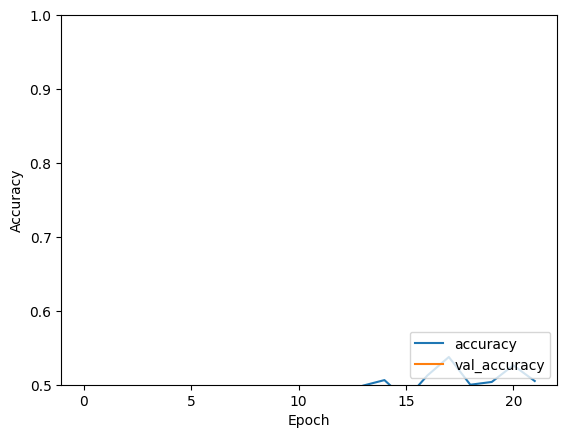

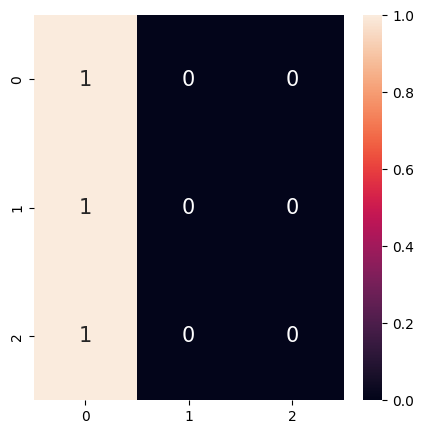

In [312]:
#############
# ACTUALLY DOING EVERYTHING

fragment_channels = 64

dataset_train_X, dataset_test_X, dataset_train_Y, dataset_test_Y, _resolution = do_data(
    "./data/Small_Hotel_Reviews.csv",
    _fragment_channels = fragment_channels,
    _pad_vectors = True
)

print(
    "  >>> training data:",
    "\n      >>> textures (number of reviews):",
    "\n            " + str(len(dataset_train_X)),
    "\n      >>> _resolution (dimensions of texture in fragments):",
    "\n            " + str(len(dataset_train_X[0])),
    "\n      >>> colour space dimensionality (channels per fragment):",
    "\n            " + str(len(dataset_train_X[0][0]))
)

_model, _history = make_model(dataset_train_X, dataset_test_X, dataset_train_Y, dataset_test_Y, _resolution, fragment_channels)

confusion_matrix = evaluate_model(_model, dataset_test_X, dataset_test_Y)
plotAll(_history, confusion_matrix)

## dereferencing for garbage collection
dataset_train_X = None
dataset_test_X = None
dataset_train_Y = None
dataset_test_Y = None
_model = None
_history = None


# Task 2 Convolution Neural Network

#### a) 

##### Sources used to guide this task: "https://medium.com/x8-the-ai-community/solving-class-imbalance-problem-in-cnn-9c7a5231c478" and "https://medium.com/@seelcs12/cnns-for-imbalanced-image-classification-with-tensorflow-7284a8c4a2e4"

We start by loading the dataset from CIFAR-10 with all 60000 images. We split them into our training and test data. In addition we also normalize the images as it will be easier for our model to learn from.

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

Our task at hand was to create a binary CNN with the CIFAR-10 dataset. After going through most of the data we found out that changing the labels into a binary relation would help greatly into making this CNN fit for our task. In our case we chose that this model should identify frogs, which in the dataset was the label `[6]`. So we start by going through the dataset to set our new labels for our data.

In [ ]:
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

#### Undersampling the data

After some careful feedback and consideration we found that the dataset would be quite imbalanced. As we only have 5000 training images of frogs and 45000 non frog pictures. To make the model understand the frog we decided to undersample our dataset so we have even frog and non frog pictures. We tried to this with our test data as well, but thought that more pictures would mean better results for our model, we come back to this in our evaluation.

In [ ]:
x_tr_frog = []
y_tr_frog = []
for n in range(len(y_train)):
    if y_train[n] == [1]:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([1])

for n in range(len(y_train)):
    if len(x_tr_frog) < 10000:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([0])

x_tr_frog = np.array(x_tr_frog)
y_tr_frog = np.array(y_tr_frog)

##### <u>The model</u>

Creating the function `make_model()`, so we can create two different models with the same model building blocks. Start with 32 units of `Conv2D` with the input size set to our pictures size. Went with the solid `relu` activation. Then a `BatchNormalization` which speeds up our CNN to find an optimal solution. Then a `MaxPooling2D` which reduces the shape of our pictures and extract valueable features of the picture. This is our base layer which we use two times in our model before we add the last `Conv2D` and `BatchNormalization`. In the last 'layer' we start adding our `Dense` units to actually train the model. We use the same activation throughout the model, in addition we add a `kernel_regularizer` which helps the model's weights. We also add `Dropout`'s units to help with overfitting. Our last `Dense` unit will serve as our output and therefore have the activation `sigmoid` to get the models prediction between 0 and 1. After quite some testing and checking our over/under-fitting graphs and saw quite many spikes we decided to increase our batch size to 128 to better comlpy with the big test set.

In [93]:
def make_model(metric, x_train, y_train, x_val, y_val):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 128,
            epochs = 50,
            validation_data = (x_val, y_val),
            callbacks = [early_stopping]
        )
        return model, history

#### Training the model.

# Question to TA: Would it be optimal to compare two different models and explain why the one model is better than the other, or is it better present one model and explain what makes it good.

After some careful consideration and testing with different metrics. We decided to compare two of our models, one with the metric `accuracy`, like our previous models, and one with the `F1-score` metric. The two models use the exact same training set and test set. Both also have an early stopping when our `val_loss` does not improve over five epochs. After training both models we start comparing them in our evaluation. We chose to go for a medium threshold on our `F1Score` since this was quite better than the low and high thresholds.

In [94]:
acc_model, acc_history = make_model('accuracy', x_tr_frog, y_tr_frog, x_test, y_test)

f1_model, f1_history = make_model(F1Score(threshold=0.5, average='micro'), x_tr_frog, y_tr_frog, x_test, y_test)

##### <u>Evaluation graphs</u>
Creating `confusion_matrix` for each model to compare what makes them different. Uses `seaborn` to show the matrices.

In [ ]:
def made_predictions(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_acc = acc_model.predict(x_test)
y_pred_acc = made_predictions(y_pred_acc)
best_cf = confusion_matrix(y_test, y_pred_acc)

y_pred_f1 = f1_model.predict(x_test)
y_pred_f1 = made_predictions(y_pred_f1)
worse_cf = confusion_matrix(y_test, y_pred_f1)

fig, ax = plt.subplots(1,2)
fig.tight_layout()
sns.heatmap(best_cf, annot=True, cmap='Blues', fmt='d', ax=ax[0])
sns.heatmap(worse_cf, annot=True, cmap='Blues', fmt='d', ax=ax[1])
fig.savefig('./matplotlib_data/conf_mat_CNN')
fig.show()

#### Checking underfitting and overfitting

As we mentioned the huge imbalance in our dataset, it is important to chech if our models actually overfit or underfit in our models. We create these two graphs using seaborn to check.

============= SKAL DETTE BORT, ELLER VÆRE MED??? ==========================
Since overfitting and underfitting is quite significant with these kinds of tasks we have to make sure it doesn't do that. As we see with our pictures, the best model is not specially overfitted or underfitted which is quite good. For our worse model we can see it jumps quite much between overfitting and not. This could mean our data is not getting augmented enough in the model for a high `f1_score` metric to better the model.

In [ ]:
plt.plot(acc_history.history['accuracy'], label='accuracy')
plt.plot(acc_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
plt.savefig('./matplotlib_data/over_acc_CNN')

test_loss, test_acc = acc_model.evaluate(x_test, y_test, verbose=2)

In [ ]:
plt.plot(f1_history.history['f1_score'], label='f1_score')
plt.plot(f1_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('f1_score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
plt.savefig('./matplotlib_data/over_f1_CNN')

test_loss, test_acc = f1_model.evaluate(x_test, y_test, verbose=2)

#### Task 2b)

Found these pictures from Google:

* <u>Image 1</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.wcs.org%2Fget-involved%2Fupdates%2Ffascinating-frogs&psig=AOvVaw28_HGqOe7S2sxjPK3bsI5N&ust=1744278715616000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCKDFld_WyowDFQAAAAAdAAAAABAE

* <u>Image 2</u> 
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.twinkl.pt%2Fteaching-wiki%2Ffrog&psig=AOvVaw0bdQuBJB9qO9gkRwCWvou-&ust=1744633397275000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCPCGuIGA1YwDFQAAAAAdAAAAABAE

* <u>Image 3</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.nytimes.com%2Fwirecutter%2Freviews%2Fnew-dog-checklist%2F&psig=AOvVaw2ZPUsP1HTJbZhOYM2tqHPx&ust=1744633423068000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCND_iI6A1YwDFQAAAAAdAAAAABAE

* <u>Image 4</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.goodwood.com%2Fgrr%2Ff1%2Fthe-nine-best-f1-cars-of-all-time%2F&psig=AOvVaw0_NSf08TH2_7ChAB8GfZhd&ust=1744633440992000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCNi76pWA1YwDFQAAAAAdAAAAABAE

Used Tensorflows own `load_img` to convert the pictures to the right size for our models. Then we show how the pictures will look for our models, to see if they have any meaningful similarities that could make the model make a wrong prediction.

##### Conversion
After that we convert the images into their array form so we can actually use them in our model. Not much meaningful parameters are used as we just convert and normalize the array as we did earlier.

In [ ]:
# Showing the pictures we are using to test the models
images = []

img_1 = tf.keras.utils.load_img('./media/frog_6.jpg', target_size=(32, 32))
img_2 = tf.keras.utils.load_img('./media/frog_4.jpg', target_size=(32, 32))
img_3 = tf.keras.utils.load_img('./media/dog_2.jpg', target_size=(32, 32))
img_4 = tf.keras.utils.load_img('./media/f1.jpg', target_size=(32, 32))

images.append(img_1)
images.append(img_2)
images.append(img_3)
images.append(img_4)

fig, ax = plt.subplots(2, 2)
fig.tight_layout()
ax = ax.flatten()

images_for_model = []
num = 1

for img, ax in zip(images, ax):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.array(img_array) / 255.0 # Normalize
    images_for_model.append(img_array)
    ax.imshow(img_array)
    ax.set_title(f'Image {num}')
    ax.axis('off')
    num += 1

plt.show()

##### <u>Prediction</u>

Before we actually predict our images we first have to add a batch so that our model acctually can use our arrays. When we get our prediction back we make it into a percentage so it is more readable. Here we also added a threshhold to decide if we think our models actually predicted right or not. We found that if the model was 70% sure it was a frog it mostly was right. We can see all the predictions below.

In [ ]:
# Actual predictions
print("Hi! I'm Accuracy and I think that: ")
for num in range(len(images_for_model)):
    img = images_for_model[num]
    img = tf.expand_dims(img, 0) # Create a batch
    pred = acc_model.predict(img)
    pred = pred[0][0] * 100
    print(f"    Image {num + 1} is: ", end="")
    if pred > 70:
        print(f'{pred:.2f}% a frog.')
    else:
        print(f'{100 - pred:.2f}% not a frog')

print("\n-----------CHANGING MODEL-----------\n")

print("Hi! I'm F1 and I actually think that: ")
for num in range(len(images_for_model)):
    img = images_for_model[num]
    img = tf.expand_dims(img, 0) # Create a batch
    pred = f1_model.predict(img)
    pred = pred[0][0] * 100
    print(f"    Image {num + 1} is: ", end="")
    if pred > 70:
        print(f'{pred:.2f}% a frog.')
    else:
        print(f'{100 - pred:.2f}% not a frog')

### Conclusion of task 1.

...

### Conclusion of task 2.

To summarize quitle short, we have now created two convolutional neural network as a binary classifier of one category. And tested them with pictures from the internet to see if it actually could predict a frog or not. When doing this task is starts quite simple by just building a neural network like we did in task 1. But when actually trying to optimize and find the right parameters, metric, training or test size would be quite tidy to do. When just comparing the two models there is quite significant changes in both. Like when we see at their confusion matrices.

